In [22]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from collections import defaultdict
from pathlib import Path
import timm
from huggingface_hub import login
from torch.utils.data import DataLoader, WeightedRandomSampler

# Aggiungi il tuo src al path se necessario
import sys
sys.path.append(".")
from src.dataset import HistologicalImageDataset

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Transforms coerenti con UNI (224x224, ImageNet norm)
import torchvision.transforms as T
transform = T.Compose([
    T.Resize((224, 224)),
    T.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

DATA_DIR = "/data/BREAKHIS/val"  # <-- modifica
dataset = HistologicalImageDataset(DATA_DIR, transform=transform)
loader  = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=4)

print(f"Classi: {dataset.class_names}")
print(f"Device: {device}")

Loading from /data/BREAKHIS/val...
Loaded 6832 samples, 8 classes
Class distribution:
  adenosis: 541 (7.9%)
  fibroadenoma: 692 (10.1%)
  phyllodes_tumor: 423 (6.2%)
  tubular_adenoma: 601 (8.8%)
  ductal_carcinoma: 2769 (40.5%)
  lobular_carcinoma: 601 (8.8%)
  mucinous_carcinoma: 757 (11.1%)
  papillary_carcinoma: 448 (6.6%)
Classi: ['adenosis', 'fibroadenoma', 'phyllodes_tumor', 'tubular_adenoma', 'ductal_carcinoma', 'lobular_carcinoma', 'mucinous_carcinoma', 'papillary_carcinoma']
Device: cuda


In [24]:
CFG = dict(
    data_dir    = "/data/BREAKHIS",   
    img_size    = 224,
    batch_size  = 16,
    num_workers = 8,
    lr_head     = 1e-3,
    lr_backbone = 1e-5,
    epochs      = 20,
    weight_decay= 0.01,
    warmup_steps= 100,
    label_smoothing = 0.1,
    seed        = 42,
    output_dir  = Path("checkpoints/uni_finetuned"),
)
CFG["output_dir"].mkdir(parents=True, exist_ok=True)
torch.manual_seed(CFG["seed"])
np.random.seed(CFG["seed"])

In [25]:
train_tf = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomApply([T.RandomRotation((90, 90))], p=0.5),
    T.RandomApply([T.ColorJitter(0.2, 0.2, 0.1, 0.05)], p=0.5),
    T.Resize((CFG["img_size"], CFG["img_size"])),
    T.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])
eval_tf = T.Compose([
    T.Resize((CFG["img_size"], CFG["img_size"])),
    T.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

train_ds = HistologicalImageDataset(f"{CFG['data_dir']}/train", transform=train_tf)
val_ds   = HistologicalImageDataset(f"{CFG['data_dir']}/val",   transform=eval_tf)
test_ds  = HistologicalImageDataset(f"{CFG['data_dir']}/test",  transform=eval_tf)

# Sampler bilanciato
counts  = np.bincount(train_ds.labels)
weights = torch.from_numpy((1.0 / counts)[train_ds.labels]).double()
sampler = WeightedRandomSampler(weights, len(weights), replacement=True)

kw = dict(batch_size=CFG["batch_size"], num_workers=CFG["num_workers"],
          pin_memory=True, persistent_workers=True)
train_loader = DataLoader(train_ds, sampler=sampler, drop_last=True, **kw)
val_loader   = DataLoader(val_ds,  shuffle=False, **kw)
test_loader  = DataLoader(test_ds, shuffle=False, **kw)

CLASS_NAMES = train_ds.class_names
N_CLASSES   = len(CLASS_NAMES)
print(f"Classi: {CLASS_NAMES}")

Loading from /data/BREAKHIS/train...


Loading dataset from disk:   0%|          | 0/29 [00:00<?, ?it/s]

Loaded 25880 samples, 8 classes
Class distribution:
  adenosis: 1139 (4.4%)
  fibroadenoma: 3685 (14.2%)
  phyllodes_tumor: 1419 (5.5%)
  tubular_adenoma: 1642 (6.3%)
  ductal_carcinoma: 11717 (45.3%)
  lobular_carcinoma: 1927 (7.4%)
  mucinous_carcinoma: 2446 (9.5%)
  papillary_carcinoma: 1905 (7.4%)
Loading from /data/BREAKHIS/val...
Loaded 6832 samples, 8 classes
Class distribution:
  adenosis: 541 (7.9%)
  fibroadenoma: 692 (10.1%)
  phyllodes_tumor: 423 (6.2%)
  tubular_adenoma: 601 (8.8%)
  ductal_carcinoma: 2769 (40.5%)
  lobular_carcinoma: 601 (8.8%)
  mucinous_carcinoma: 757 (11.1%)
  papillary_carcinoma: 448 (6.6%)
Loading from /data/BREAKHIS/test...
Loaded 6833 samples, 8 classes
Class distribution:
  adenosis: 540 (7.9%)
  fibroadenoma: 693 (10.1%)
  phyllodes_tumor: 423 (6.2%)
  tubular_adenoma: 602 (8.8%)
  ductal_carcinoma: 2769 (40.5%)
  lobular_carcinoma: 602 (8.8%)
  mucinous_carcinoma: 757 (11.1%)
  papillary_carcinoma: 447 (6.5%)
Classi: ['adenosis', 'fibroadenoma',

In [26]:
import torch
import torch.nn as nn
import timm
from peft import LoraConfig
from peft.tuners.lora import LoraModel

class UNILoRAClassifier(nn.Module):
    def __init__(self, n_classes, dropout=0.1):
        super().__init__()

        # Backbone timm puro
        backbone = timm.create_model("hf-hub:MahmoodLab/uni", pretrained=True, init_values=1e-5, dynamic_img_size=True)

        # Config LoRA (NO task_type)
        lora_config = LoraConfig(
            r=8,
            lora_alpha=32,
            target_modules=["qkv", "proj", "fc1", "fc2"],  # nomi reali timm
            lora_dropout=0.1,
            bias="none"
        )

        # Inject LoRA direttamente
        self.backbone = LoraModel(backbone, lora_config, adapter_name="default")


        embed_dim = 1024  # ViT-L

        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, n_classes),
        )

    def forward(self, x):
        features = self.backbone(x)   # timm forward puro
        return self.head(features)


model = UNILoRAClassifier(N_CLASSES).to(device)

In [27]:
#load pretrained 
checkpoint = torch.load("checkpoints/uni_finetuned/best_model.pt", map_location=device)
model.load_state_dict(checkpoint)

<All keys matched successfully>

In [30]:
def attention_rollout(attn_by_layer):
    """
    Propaga l'attenzione attraverso i layer per ottenere
    l'importanza effettiva di ogni patch sul CLS finale.
    attn_by_layer: {layer: tensor [H, N, N]}
    """
    rollout = torch.eye(197)
    for l in sorted(attn_by_layer.keys()):
        attn = attn_by_layer[l].mean(0)  # [N, N] media heads
        attn = attn + torch.eye(197)     # residual connection
        attn = attn / attn.sum(-1, keepdim=True)
        rollout = attn @ rollout
    return rollout[0, 1:]  # importanza CLS → patches [196]

In [ ]:
def pruning_accuracy_drop(model, img, label, device, score, keep_ratio=0.5):
    """
    Pota le patch con score più basso e misura il drop di accuracy.
    Score migliore = drop minore quando mantieni le patch top-k.
    """
    # Calcola score per questo sample
    k = int(196 * keep_ratio)
    topk_idx = score.argsort(descending=True)[:k]  # patch più importanti

    # Forward con solo le patch selezionate
    # (approssimazione: maschera le patch non selezionate a zero)
    masked = img.clone()
    all_idx = set(range(196))
    prune_idx = all_idx - set(topk_idx.tolist())
    for p in prune_idx:
        r, c = divmod(p, 14)
        masked[:, :, r*16:(r+1)*16, c*16:(c+1)*16] = 0.

    with torch.no_grad():
        prob_pruned = model(masked.to(device)).softmax(-1)[0, label].item()
    return prob_pruned

In [31]:
import types

def get_rollout_gt(model, img, device):
    """Attention rollout come ground truth"""
    attn_layers = {}
    orig = {}

    def make_hook(idx):
        def fwd(self, x):
            B, N, C = x.shape
            qkv = self.qkv(x).reshape(B,N,3,self.num_heads,self.head_dim).permute(2,0,3,1,4)
            q, k, v = qkv.unbind(0)
            q, k = self.q_norm(q), self.k_norm(k)
            attn = (q @ k.transpose(-2,-1) * self.scale).softmax(-1)
            attn_layers[idx] = attn[0].detach().cpu()  # [H, N, N]
            x = (self.attn_drop(attn) @ v).transpose(1,2).reshape(B,N,C)
            return self.proj_drop(self.proj(x))
        return fwd

    for i, block in enumerate(model.backbone.model.blocks):
        orig[i] = block.attn.forward
        block.attn.forward = types.MethodType(make_hook(i), block.attn)

    with torch.no_grad():
        model(img.to(device))

    for i, block in enumerate(model.backbone.model.blocks):
        block.attn.forward = orig[i]

    return attention_rollout(attn_layers).numpy()  # [196]




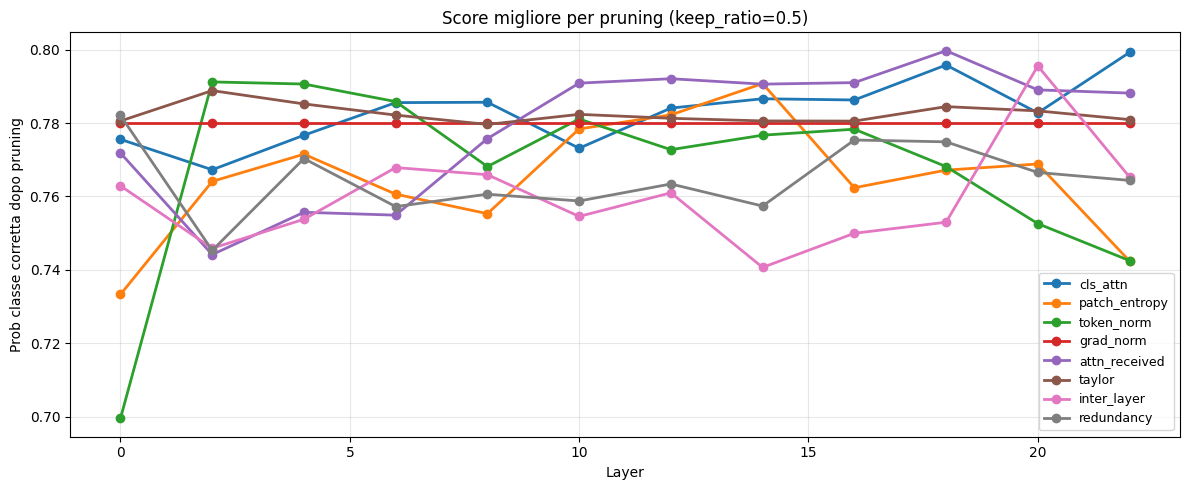

In [39]:
# Invece di gt_cache, calcola direttamente accuracy dopo pruning per ogni score
results = defaultdict(lambda: defaultdict(list))  # {layer: {score_name: [prob_pruned]}}

N_EVAL = 300  # puoi aumentare, ogni sample è solo ~9 forward pass
KEEP_RATIO = 0.5

for s in range(N_EVAL):
    img, label = val_ds[s]
    img   = img.unsqueeze(0).to(device)
    label = label.item()

    for l in range(0, 24, 2):
        scores_l = compute_all_scores(model, img, torch.tensor([label]), device, layer_idx=l)

        for score_name, score_vals in scores_l.items():
            score = score_vals[0]  # [196]
            k     = int(196 * KEEP_RATIO)
            topk  = score.argsort(descending=True)[:k]

            masked = img.clone()
            for p in set(range(196)) - set(topk.tolist()):
                r, c = divmod(p, 14)
                masked[:, :, r*16:(r+1)*16, c*16:(c+1)*16] = 0.

            with torch.no_grad():
                prob = model(masked).softmax(-1)[0, label].item()
            results[l][score_name].append(prob)

    print(f"Sample {s+1}/{N_EVAL} done", end='\r')

# Plot: prob media mantenuta per score e layer
fig, ax = plt.subplots(figsize=(12, 5))
layer_ids_sorted = sorted(results.keys())
score_names = list(results[layer_ids_sorted[0]].keys())

for score_name in score_names:
    means = [np.mean(results[l][score_name]) for l in layer_ids_sorted]
    ax.plot(layer_ids_sorted, means, marker='o', linewidth=2, label=score_name)

ax.set_xlabel("Layer"); ax.set_ylabel("Prob classe corretta dopo pruning")
ax.set_title(f"Score migliore per pruning (keep_ratio={KEEP_RATIO})")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
def compute_all_scores(model, imgs, labels, device, layer_idx):
    import types
    cache = {}
    orig = {}

    def make_hook(idx):
        def fwd(self, x):
            B, N, C = x.shape
            qkv = self.qkv(x).reshape(B,N,3,self.num_heads,self.head_dim).permute(2,0,3,1,4)
            q, k, v = qkv.unbind(0)
            q, k = self.q_norm(q), self.k_norm(k)
            attn = (q @ k.transpose(-2,-1) * self.scale).softmax(-1)
            if idx == layer_idx:
                cache['attn']   = attn.detach().cpu()
                cache['tokens'] = x.detach()          # mantieni su device per grad
            if idx == layer_idx - 1:
                cache['tokens_prev'] = x.detach().cpu()
            if idx == len(list(model.backbone.model.blocks)) - 1:
                cache['tokens_final'] = x.detach().cpu()
            x = (self.attn_drop(attn) @ v).transpose(1,2).reshape(B,N,C)
            return self.proj_drop(self.proj(x))
        return fwd

    for i, block in enumerate(model.backbone.model.blocks):
        orig[i] = block.attn.forward
        block.attn.forward = types.MethodType(make_hook(i), block.attn)

    imgs_g = imgs.to(device).requires_grad_(True)
    # Abilita grad sui token intermedi
    cache['tokens'] = None
    def save_token_grad(grad):
        cache['token_grad'] = grad.detach().cpu()

    logits = model(imgs_g)
    loss   = logits[torch.arange(len(labels)), labels].sum()
    loss.backward()

    for i, block in enumerate(model.backbone.model.blocks):
        block.attn.forward = orig[i]

    # Registra hook gradiente sui token al layer target
    # (il grad è già calcolato — usiamo imgs_g.grad come proxy pixel)
    attn   = cache['attn']
    tokens = cache['tokens'].cpu()

    scores = {}

    # 1. CLS attention
    scores['cls_attn'] = attn[:,:,0,1:].mean(1)

    # 2. Patch entropy
    patch_attn = attn[:,:,1:,1:]
    ent = -(patch_attn * (patch_attn + 1e-8).log()).sum(-1).mean(1)
    scores['patch_entropy'] = -ent

    # 3. Token norm
    scores['token_norm'] = tokens[:,1:].norm(dim=-1)

    # 4. Change rate
    if 'tokens_prev' in cache:
        scores['change_rate'] = -(tokens[:,1:] - cache['tokens_prev'][:,1:]).norm(dim=-1)

    # 5. Grad norm (pixel level)
    if imgs_g.grad is not None:
        B, P = imgs_g.shape[0], 14
        grad_patch = imgs_g.grad.reshape(B,3,P,16,P,16).abs().mean((1,3,5))
        scores['grad_norm'] = grad_patch.reshape(B,-1).cpu()

    # 6. Attenzione ricevuta
    scores['attn_received'] = attn[:,:,1:,1:].sum(-2).mean(1)

    # 7. Taylor score — grad rispetto ai token (approx con grad pixel→patch)
    if imgs_g.grad is not None:
        B, P = imgs_g.shape[0], 14
        grad_p = imgs_g.grad.reshape(B,3,P,16,P,16).abs().mean((1,3,5)).reshape(B,-1).cpu()
        scores['taylor'] = (tokens[:,1:].norm(dim=-1) * grad_p)  # activation × grad

    # 8. Inter-layer score — quanto il token cambia dal layer corrente al finale
    if 'tokens_final' in cache:
        scores['inter_layer'] = -(tokens[:,1:] - cache['tokens_final'][:,1:]).norm(dim=-1)

    # 9. Token redundancy (cosine similarity media con gli altri token)
    t_norm = torch.nn.functional.normalize(tokens[:,1:], dim=-1)
    sim    = (t_norm @ t_norm.transpose(-1,-2)).mean(-1)  # [B, N-1]
    scores['redundancy'] = -sim  # bassa ridondanza = informativo

    return scores

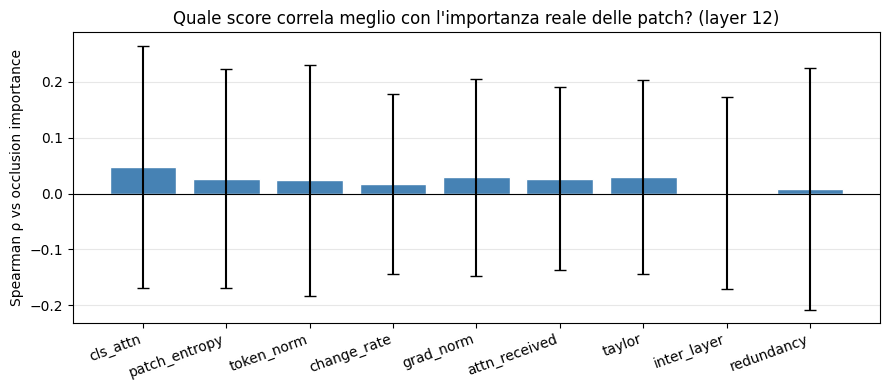

In [37]:
from scipy.stats import spearmanr

correlations = defaultdict(lambda: defaultdict(list))

for s in range(N_EVAL):
    img, label = val_ds[s]
    img_batch   = img.unsqueeze(0)
    label_batch = torch.tensor([label])

    for l in range(0, 24, 2):
        scores_l = compute_all_scores(model, img_batch, label_batch, device, layer_idx=l)
        for score_name, score_vals in scores_l.items():
            rho, _ = spearmanr(score_vals[0].numpy(), gt_cache[s])
            correlations[l][score_name].append(rho)

    print(f"Sample {s+1}/{N_EVAL} done", end='\r')

# Plot
score_names = list(correlations[12].keys())
means = [np.mean(correlations[12][k]) for k in score_names]
stds  = [np.std(correlations[12][k])  for k in score_names]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(score_names, means, yerr=stds, color='steelblue', edgecolor='white', capsize=4)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel("Spearman ρ vs occlusion importance")
ax.set_title("Quale score correla meglio con l'importanza reale delle patch? (layer 12)")
ax.grid(alpha=0.3, axis='y')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

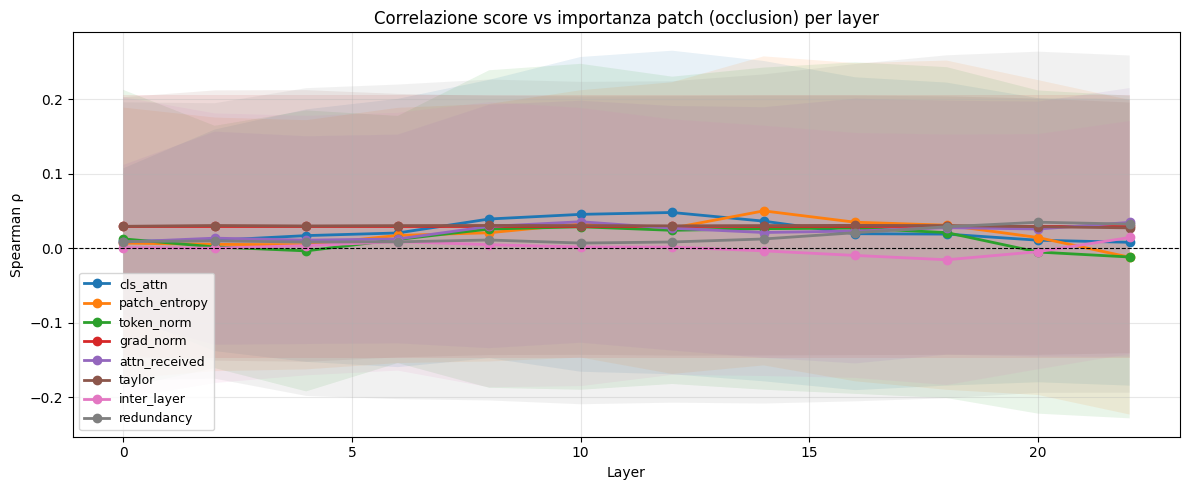

In [38]:
fig, ax = plt.subplots(figsize=(12, 5))

layer_ids_sorted = sorted(correlations.keys())
score_names = list(correlations[layer_ids_sorted[0]].keys())

for score_name in score_names:
    rho_means = [np.mean(correlations[l][score_name]) for l in layer_ids_sorted]
    rho_stds  = [np.std(correlations[l][score_name])  for l in layer_ids_sorted]
    ax.plot(layer_ids_sorted, rho_means, marker='o', linewidth=2, label=score_name)
    ax.fill_between(layer_ids_sorted,
                    [m-s for m,s in zip(rho_means, rho_stds)],
                    [m+s for m,s in zip(rho_means, rho_stds)],
                    alpha=0.1)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel("Layer"); ax.set_ylabel("Spearman ρ")
ax.set_title("Correlazione score vs importanza patch (occlusion) per layer")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()